In [13]:
import os
import shutil
import random
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, Rescaling
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import tf2onnx


In [14]:

# ----------------------------
# CONFIG
# ----------------------------
IMG_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 20

GOOD_DIR = r"D:\FYP\Datasets\solar_cell_EL_image\solar_cell_EL_image\PVELAD\EL2021\othertypes\good"
DEFECT_DIR = r"D:\FYP\Datasets\solar_cell_EL_image\solar_cell_EL_image\PVELAD\EL2021\test\JPEGImages"

PARENT_DIR = os.path.dirname(GOOD_DIR)
TRAIN_DIR = os.path.join(PARENT_DIR, "train")
VAL_DIR = os.path.join(PARENT_DIR, "val")

VAL_SPLIT = 0.2
SEED = 42


In [15]:

# ----------------------------
# PREPARE FOLDER STRUCTURE
# ----------------------------
def prepare_split_folder(src_dir, dst_train, dst_val):
    os.makedirs(dst_train, exist_ok=True)
    os.makedirs(dst_val, exist_ok=True)
    files = [f for f in os.listdir(src_dir) if os.path.isfile(os.path.join(src_dir, f))]
    random.shuffle(files)

    val_count = int(len(files) * VAL_SPLIT)
    val_files = files[:val_count]
    train_files = files[val_count:]

    for f in train_files:
        shutil.copy(os.path.join(src_dir, f), os.path.join(dst_train, f))

    for f in val_files:
        shutil.copy(os.path.join(src_dir, f), os.path.join(dst_val, f))

# Only create if not already prepared
if not os.path.exists(TRAIN_DIR):
    print("Preparing dataset folders...")
    prepare_split_folder(GOOD_DIR, os.path.join(TRAIN_DIR, "good"), os.path.join(VAL_DIR, "good"))
    prepare_split_folder(DEFECT_DIR, os.path.join(TRAIN_DIR, "defect"), os.path.join(VAL_DIR, "defect"))


In [16]:

# ----------------------------
# DATASETS
# ----------------------------
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False,
    seed=SEED
)

# Save class names before prefetch (important!)
class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

# Add normalization (0–1 scaling)
normalization_layer = Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# Prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)


Found 24403 files belonging to 2 classes.
Found 6100 files belonging to 2 classes.
Classes: ['defect', 'good']


In [17]:

# ----------------------------
# CLASS WEIGHTS (for imbalance)
# ----------------------------
all_labels = []
for _, labels in train_ds.unbatch():
    all_labels.append(np.argmax(labels.numpy()))
all_labels = np.array(all_labels)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_labels),
    y=all_labels
)
class_weights = {i: w for i, w in enumerate(class_weights)}
print("Class Weights:", class_weights)


Class Weights: {0: 0.7964425587467363, 1: 1.3433337003192778}


In [18]:

# ----------------------------
# MODEL - ResNet50
# ----------------------------
def create_resnet50_model(num_classes, input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    base = ResNet50(weights="imagenet", include_top=False, input_shape=input_shape)
    x = GlobalAveragePooling2D(name="gap")(base.output)
    x = BatchNormalization(name="bn_head")(x)
    x = Dropout(0.5, name="dropout_head")(x)
    x = Dense(512, activation="relu", name="dense_512")(x)
    x = BatchNormalization(name="bn_dense")(x)
    x = Dropout(0.3, name="dropout_2")(x)
    out = Dense(num_classes, activation="softmax", name="predictions")(x)
    model = Model(inputs=base.input, outputs=out, name="ResNet50_binary")
    return model

model = create_resnet50_model(num_classes)
model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()


Model: "ResNet50_binary"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 256, 256, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 262, 262, 3)          0         ['input_2[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 128, 128, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 128, 128, 64)         256       ['conv1_conv[0][0]']          
 on)                                                                                

In [19]:

# ----------------------------
# TRAIN
# ----------------------------
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights
)


Epoch 1/20
3051/3051 [==============================] - 2791s 908ms/step - loss: 0.4757 - accuracy: 0.8058 - val_loss: 0.8997 - val_accuracy: 0.8231
Epoch 2/20
3051/3051 [==============================] - 2704s 886ms/step - loss: 0.3090 - accuracy: 0.8819 - val_loss: 0.1737 - val_accuracy: 0.9367
Epoch 3/20
3051/3051 [==============================] - 2706s 887ms/step - loss: 0.2530 - accuracy: 0.9060 - val_loss: 0.1932 - val_accuracy: 0.9328
Epoch 4/20
3051/3051 [==============================] - 2711s 888ms/step - loss: 0.2000 - accuracy: 0.9294 - val_loss: 0.5282 - val_accuracy: 0.7054
Epoch 5/20
3051/3051 [==============================] - 2704s 886ms/step - loss: 0.1768 - accuracy: 0.9389 - val_loss: 0.2333 - val_accuracy: 0.9370
Epoch 6/20
3051/3051 [==============================] - 2723s 892ms/step - loss: 0.1401 - accuracy: 0.9534 - val_loss: 0.1358 - val_accuracy: 0.9489
Epoch 7/20
3051/3051 [==============================] - 2717s 890ms/step - loss: 0.1206 - accuracy: 0.9631

In [20]:
h5_path = os.path.join(PARENT_DIR, "resnet50_good_defect.h5")
model.save(h5_path)
print(f"✅ Saved Keras model to: {h5_path}")

C:\Users\Akiellan\AppData\Roaming\Python\Python311\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


✅ Saved Keras model to: D:\FYP\Datasets\solar_cell_EL_image\solar_cell_EL_image\PVELAD\EL2021\othertypes\resnet50_good_defect.h5


In [21]:

onnx_path = os.path.join(PARENT_DIR, "resnet50_good_defect.onnx")
spec = (tf.TensorSpec((None, IMG_SIZE, IMG_SIZE, 3), tf.float32, name="input"),)
onnx_model, _ = tf2onnx.convert.from_keras(model, input_signature=spec, opset=13)
with open(onnx_path, "wb") as f:
    f.write(onnx_model.SerializeToString())
print(f"✅ Saved ONNX model to: {onnx_path}")


✅ Saved ONNX model to: D:\FYP\Datasets\solar_cell_EL_image\solar_cell_EL_image\PVELAD\EL2021\othertypes\resnet50_good_defect.onnx


Validation Accuracy: 0.9285

Classification Report:
              precision    recall  f1-score   support

      defect       0.92      0.97      0.94      3830
        good       0.95      0.86      0.90      2270

    accuracy                           0.93      6100
   macro avg       0.93      0.91      0.92      6100
weighted avg       0.93      0.93      0.93      6100


Confusion Matrix:
 [[3717  113]
 [ 323 1947]]


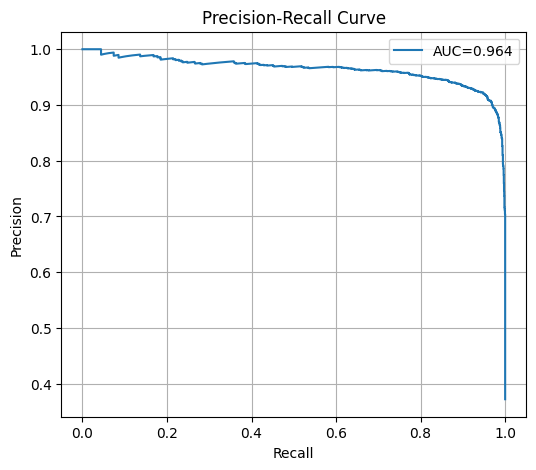

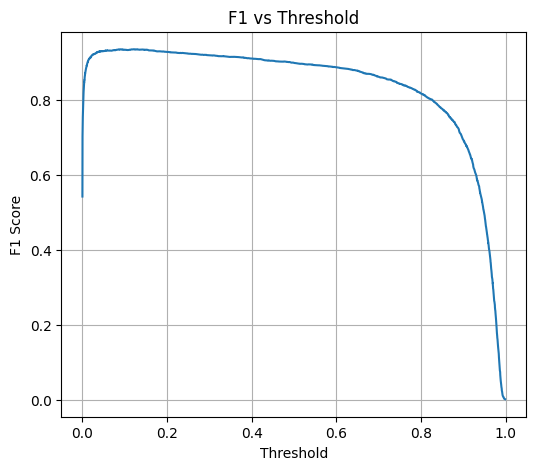

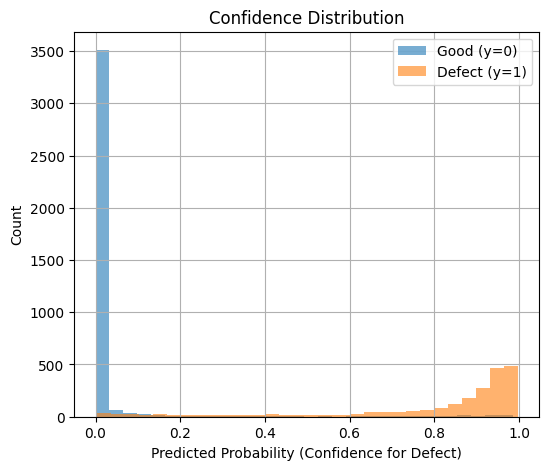

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, f1_score, accuracy_score, auc
import numpy as np

y_true = []
y_pred = []
y_prob = []

for images, labels in val_ds:
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)
    
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(preds)
    y_prob.extend(probs[:, 1])  
    
y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

acc = accuracy_score(y_true, y_pred)
print(f"Validation Accuracy: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:\n", cm)

precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"AUC={pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()
plt.show()

f1_scores = []
for t in thresholds:
    preds = (y_prob >= t).astype(int)
    f1 = f1_score(y_true, preds)
    f1_scores.append(f1)

plt.figure(figsize=(6, 5))
plt.plot(thresholds, f1_scores)
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 vs Threshold")
plt.grid()
plt.show()

plt.figure(figsize=(6, 5))
plt.hist(y_prob[y_true == 0], bins=30, alpha=0.6, label="Good (y=0)")
plt.hist(y_prob[y_true == 1], bins=30, alpha=0.6, label="Defect (y=1)")
plt.xlabel("Predicted Probability (Confidence for Defect)")
plt.ylabel("Count")
plt.title("Confidence Distribution")
plt.legend()
plt.grid()
plt.show()


In [27]:
import matplotlib.pyplot as plt

# ----------------------------
# TRAINING HISTORY PLOT
# ----------------------------
def plot_training_history(history):
    # Accuracy plot
    plt.figure(figsize=(6, 5))
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Training & Validation Accuracy")
    plt.legend()
    plt.grid()
    plt.show()

    # Loss plot
    plt.figure(figsize=(6, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training & Validation Loss")
    plt.legend()
    plt.grid()
    plt.show()

# Example usage:
# history = model.fit(...)
# plot_training_history(history)


In [28]:
from ultralytics import YOLO

# Load trained YOLOv8 model (replace with your weights path)
model = YOLO(r"D:\FYP\Trial codes\runs\detect\100epochs_512res_yolov8s_preprocessing_class_balancing\weights\best.pt")  # or "runs/detect/train/weights/best.pt"

# Export to ONNX
model.export(format="onnx", opset=12)  # opset>=11 is recommended


Ultralytics 8.3.195  Python-3.11.8 torch-2.7.1+cu118 CPU (AMD Ryzen 7 6800H with Radeon Graphics)
Model summary (fused): 72 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs

PyTorch: starting from 'D:\FYP\Trial codes\runs\detect\100epochs_512res_yolov8s_preprocessing_class_balancing\weights\best.pt' with input shape (1, 3, 512, 512) BCHW and output shape(s) (1, 7, 5376) (21.5 MB)
requirements: Ultralytics requirement ['onnxslim>=0.1.67'] not found, attempting AutoUpdate...
Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com

requirements: AutoUpdate success  18.7s
WARNING requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.17.0 opset 12...
ONNX: slimming with onnxslim 0.1.70...
ONNX: export success  23.2s, saved as 'D:\FYP\Trial codes\runs\detect\100epochs_512res_yolov8s_preprocessing_class_balancing\weights\best.onnx' (42.6

'D:\\FYP\\Trial codes\\runs\\detect\\100epochs_512res_yolov8s_preprocessing_class_balancing\\weights\\best.onnx'